# **Notebook 2: Data Preparation**
## Assignment: Hybrid RAG & Fine-Tuning for Customer Support
---

### TO-DO: Before Running This Notebook

**Files you NEED:**
- [ ] `sampled_data.csv` — Created by Notebook 1
- [ ] `corporate_policies/` folder with `.md` SOP files
- [ ] Internet access (to download the tokenizer)

**Files this notebook will CREATE:**
- [ ] `./tokenized_train/`, `./tokenized_valid/`, `./tokenized_test/` — HuggingFace datasets _(Required by NB6)_
- [ ] `df_test.csv` — Test set with readable text + labels _(Required by NB5 and NB7)_

---

## **Stage 2: Data Preparation**
### **Task 2.1: Clean and Validate Dataset**

#### **2.1.1 Remove Duplicate and Invalid Records [2 marks]**
**The Task:** Identify and remove duplicate records using normalised deduplication (lowercase + strip before comparison), plus any invalid, incomplete, or corrupted records.

**Hints & Tips:**
* Load `sampled_data.csv` from Notebook 1 first.
* Normalised dedup: create a temporary `_norm` column = `instruction.str.lower().str.strip()`, drop duplicates on it, then drop the helper column.
* Check for nulls in `instruction`, `intent`, and `category` — drop rows missing any of these targets.
* Print the number of rows removed so the cleaning is auditable.

**Why we are doing it:** To prevent degraded training from redundant or broken records, and to stop near-duplicates leaking across train/test splits later.
**How we are doing it:** Pandas normalised deduplication and null filtering.

**Learner Inference:** Exact-match dedup misses `"Where is my order?"` vs `"where is my order?"`. Normalising first catches these and keeps your splits clean.

In [1]:
import os
import pandas as pd

# 1. Load sampled_data.csv from Notebook 1
csv_candidates = [
    "sampled_data.csv",
    "../sampled_data.csv",
    "../../sampled_data.csv",
    "Files/Notebook/sampled_data.csv",
    "Files/Dataset/sampled_data.csv"
]
csv_path = None
for cand in csv_candidates:
    if os.path.exists(cand):
        csv_path = cand
        break

if not csv_path:
    raise FileNotFoundError("sampled_data.csv not found! Please run Notebook 1 first.")

df = pd.read_csv(csv_path)
initial_count = len(df)
print(f"Loaded '{csv_path}' with {initial_count:,} records.")

# 2. Check and remove nulls in essential columns
print("\n--- Missing Value Inspection ---")
null_counts = df[['instruction', 'intent', 'category']].isnull().sum()
print(null_counts)
df = df.dropna(subset=['instruction', 'intent', 'category']).copy()
after_null_count = len(df)

# 3. Normalised deduplication (lowercase + whitespace strip)
df['_norm'] = df['instruction'].astype(str).str.lower().str.strip()
dupes_count = df['_norm'].duplicated().sum()
df = df.drop_duplicates(subset=['_norm']).drop(columns=['_norm']).reset_index(drop=True)
final_count = len(df)

# 4. Auditable summary logging
print("\n--- Data Cleaning Audit ---")
print(f"Initial row count:          {initial_count:,}")
print(f"Rows dropped (nulls):       {initial_count - after_null_count:,}")
print(f"Near-duplicates dropped:    {after_null_count - final_count:,}")
print(f"Final cleaned record count: {final_count:,}")


Loaded 'sampled_data.csv' with 3,902 records.

--- Missing Value Inspection ---
instruction    0
intent         0
category       0
dtype: int64

--- Data Cleaning Audit ---
Initial row count:          3,902
Rows dropped (nulls):       0
Near-duplicates dropped:    0
Final cleaned record count: 3,902


#### **2.1.2 Standardise Dataset Formatting [2 marks]**
**The Task:** Clean the strings inside `instruction`, `intent`, and `category` by stripping whitespace and enforcing uniform casing (intents = lower, categories = upper).

**Hints & Tips:**
* Use Pandas `.str.strip()`, `.str.lower()`, `.str.upper()`.
* Always strip whitespace BEFORE lowering — trailing spaces survive `.lower()`.
* Standardised casing prevents the model treating "Refund" and "refund" as different classes.

**Why we are doing it:** To ensure raw strings are perfectly standardised before injecting them into prompt templates.
**How we are doing it:** Pandas string manipulation.

**Learner Inference:** Standardising capitalisation prevents the model from treating the same intent written two ways as two separate classes.

In [2]:
# 1. Standardise formatting: strip whitespace first, then enforce casing
df['instruction'] = df['instruction'].astype(str).str.strip()
df['intent'] = df['intent'].astype(str).str.strip().str.lower()
df['category'] = df['category'].astype(str).str.strip().str.upper()

# 2. Verify formatting consistency
print("--- Formatting Validation ---")
print(f"Total records: {len(df):,}")
print(f"Unique intents ({df['intent'].nunique()} total, lowercased):")
print(sorted(df['intent'].unique())[:5], "... and more")
print(f"\nUnique categories ({df['category'].nunique()} total, UPPERCASED):")
print(sorted(df['category'].unique()))

# Sample preview
print("\nSample formatted rows:")
display(df[['instruction', 'intent', 'category']].head(3))


--- Formatting Validation ---
Total records: 3,902
Unique intents (27 total, lowercased):
['cancel_order', 'change_order', 'change_shipping_address', 'check_cancellation_fee', 'check_invoice'] ... and more

Unique categories (11 total, UPPERCASED):
['ACCOUNT', 'CANCEL', 'CONTACT', 'DELIVERY', 'FEEDBACK', 'INVOICE', 'ORDER', 'PAYMENT', 'REFUND', 'SHIPPING', 'SUBSCRIPTION']

Sample formatted rows:


,instruction,intent,category
0,I can't talk with a human agent,contact_human_agent,CONTACT
1,I have got to locate hte bills from {{Person N...,check_invoice,INVOICE
2,"I cannot pay, help me to inform of a problem w...",payment_issue,PAYMENT


### **Task 2.2: Create Instruction-Tuning Dataset**

#### **2.2.1 Transform Records into Instruction Format [2 marks]**
**The Task:** Wrap the raw instructions and targets into a standardized `ChatML` format, forcing the assistant's response to be a strict JSON string containing the `intent` and `category`.

**Hints & Tips:**
* Use the Qwen tokenizer's `apply_chat_template(tokenize=False)`.
* The target JSON is `{"intent": "...", "category": "..."}` — built via `json.dumps()`.

**Model Selection:**
* **Qwen/Qwen2.5-1.5B-Instruct** (recommended) — fits T4, strong instruction following.
* **TinyLlama-1.1B-Chat** — lighter but weaker at structured output.
* **Llama-3-8B-Instruct** — best quality, needs >16GB VRAM even in 4-bit.
* Whatever you pick, set `MODEL_ID` here and in ALL later notebooks.

**Learner Inference:** Formatting the target as JSON establishes the exact structural rules the LoRA model learns to mimic in Stage 4.

In [3]:
import json
from transformers import AutoTokenizer

MODEL_ID = "Qwen/Qwen2.5-1.5B-Instruct"
print(f"Loading tokenizer for model: {MODEL_ID}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)

# Ensure pad_token is set
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

SYSTEM_PROMPT = (
    "You are a customer support triage assistant. Analyze the user's inquiry "
    "and output a valid JSON object containing the classified 'intent' and 'category'."
)

def format_chatml_record(row):
    # Construct strictly valid target JSON
    target_json = json.dumps({
        "intent": row["intent"],
        "category": row["category"]
    }, ensure_ascii=False)
    
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": row["instruction"]},
        {"role": "assistant", "content": target_json}
    ]
    
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)

# Apply transformation across all rows
print("Formatting records into ChatML instruction-tuning format...")
df['text'] = df.apply(format_chatml_record, axis=1)

print("\n--- Sample Formatted ChatML Sequence ---")
print(df['text'].iloc[0])


Loading tokenizer for model: Qwen/Qwen2.5-1.5B-Instruct...


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

C:\Users\hp\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\hp\.cache\huggingface\hub\models--Qwen--Qwen2.5-1.5B-Instruct. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

Formatting records into ChatML instruction-tuning format...



--- Sample Formatted ChatML Sequence ---
<|im_start|>system
You are a customer support triage assistant. Analyze the user's inquiry and output a valid JSON object containing the classified 'intent' and 'category'.<|im_end|>
<|im_start|>user
I can't talk with  a human agent<|im_end|>
<|im_start|>assistant
{"intent": "contact_human_agent", "category": "CONTACT"}<|im_end|>



#### **2.2.2 Validate Instruction Templates [2 marks]**
**The Task:** Extract the assistant's portion of the generated ChatML string and parse it with `json.loads()` to verify structural integrity.

**Hints & Tips:**
* Split the string by `<|im_start|>assistant` and parse what follows.
* If this throws `JSONDecodeError`, your formatting in 2.2.1 is broken — fix before training.
* Validate several samples, not just the first.

**Learner Inference:** A JSONDecodeError here means the model would learn broken syntax. Catching it now saves a failed training run.

In [4]:
# Extract and validate assistant JSON payloads across all records
parse_errors = 0
validated_samples = []

for idx, formatted_text in enumerate(df['text']):
    try:
        # Split by ChatML assistant token
        if "<|im_start|>assistant" in formatted_text:
            assistant_part = formatted_text.split("<|im_start|>assistant")[-1]
            # Strip ChatML end tag if present
            assistant_part = assistant_part.replace("<|im_end|>", "").strip()
        else:
            assistant_part = formatted_text.strip()
        
        parsed = json.loads(assistant_part)
        assert "intent" in parsed and "category" in parsed, "Missing required keys"
        
        if idx < 5:
            validated_samples.append((idx, parsed))
    except Exception as e:
        parse_errors += 1
        if parse_errors <= 3:
            print(f"Error at index {idx}: {e}")

print("--- Instruction Template Validation ---")
print(f"Total records validated: {len(df):,}")
print(f"JSON Parsing / Schema Errors: {parse_errors}")

if parse_errors == 0:
    print("SUCCESS: 100% of records contain structurally valid JSON matching {'intent': ..., 'category': ...}!")
    print("\nSample parsed outputs:")
    for idx, sample in validated_samples:
        print(f"  [Row {idx}]: {sample}")
else:
    raise ValueError(f"Found {parse_errors} invalid instruction templates! Fix formatting before proceeding.")


--- Instruction Template Validation ---
Total records validated: 3,902
JSON Parsing / Schema Errors: 0
SUCCESS: 100% of records contain structurally valid JSON matching {'intent': ..., 'category': ...}!

Sample parsed outputs:
  [Row 0]: {'intent': 'contact_human_agent', 'category': 'CONTACT'}
  [Row 1]: {'intent': 'check_invoice', 'category': 'INVOICE'}
  [Row 2]: {'intent': 'payment_issue', 'category': 'PAYMENT'}
  [Row 3]: {'intent': 'contact_customer_service', 'category': 'CONTACT'}
  [Row 4]: {'intent': 'check_payment_methods', 'category': 'PAYMENT'}


### **Task 2.3: Engineer Training and Retrieval Data**

#### **2.3.1 Tokenise Dataset [2 marks]**
**The Task:** Convert text sequences into tensor IDs and apply `-100` masking to padding tokens in the `labels` array.

**Hints & Tips:**
* If a token equals `tokenizer.pad_token_id`, replace it with `-100` in labels.
* `-100` is PyTorch's ignore index — the loss skips these tokens.

**Parameter Tuning:**
* `max_length`: `128` (fast, fits most Bitext prompts), `256` (safer if truncation seen), `64` (too aggressive).

**Learner Inference:** Masking isolates the loss — the model is penalised for wrong JSON, not for padding.

In [5]:
import numpy as np

MAX_LENGTH = 256
print(f"Tokenizing dataset with max_length={MAX_LENGTH}...")

# Tokenize full text sequences
tokenized_outputs = tokenizer(
    df['text'].tolist(),
    max_length=MAX_LENGTH,
    padding="max_length",
    truncation=True,
    return_tensors="np"
)

input_ids = tokenized_outputs["input_ids"]
attention_mask = tokenized_outputs["attention_mask"]

# Create labels with -100 masking on padding tokens
labels = np.copy(input_ids)
pad_id = tokenizer.pad_token_id
labels[labels == pad_id] = -100

print(f"Tokenized array shapes:")
print(f"  input_ids:      {input_ids.shape}")
print(f"  attention_mask: {attention_mask.shape}")
print(f"  labels:         {labels.shape}")

# Verify label masking
num_masked = int(np.sum(labels == -100))
num_pads = int(np.sum(input_ids == pad_id))
print(f"\nLabel masking verification:")
print(f"  Pad tokens count:     {num_pads:,}")
print(f"  Masked labels (-100): {num_masked:,} (Match: {num_masked == num_pads})")


Tokenizing dataset with max_length=256...


Tokenized array shapes:
  input_ids:      (3902, 256)
  attention_mask: (3902, 256)
  labels:         (3902, 256)

Label masking verification:
  Pad tokens count:     724,804
  Masked labels (-100): 724,804 (Match: True)


#### **2.3.2 Analyse Token Distributions [2 marks]**
**The Task:** Analyse the token-count distribution to detect truncation risks and verify the sequence-length configuration.

**Hints & Tips:**
* Count non-padding tokens per row and plot a histogram.
* If >5% of rows hit `max_length`, increase it.
* The JSON target is ~20 tokens — if truncated, the model learns incomplete output.

**Learner Inference:** Sequences hitting the ceiling mean the JSON target is getting cut off, teaching the model to produce broken output.

--- Token Distribution Statistics ---
Min length:   60 tokens
Mean length:  70.2 tokens
95th %-tile:  76.0 tokens
99th %-tile:  79.0 tokens
Max length:   82 tokens (ceiling: 256)
Truncated:    0 sequences (0.00%)


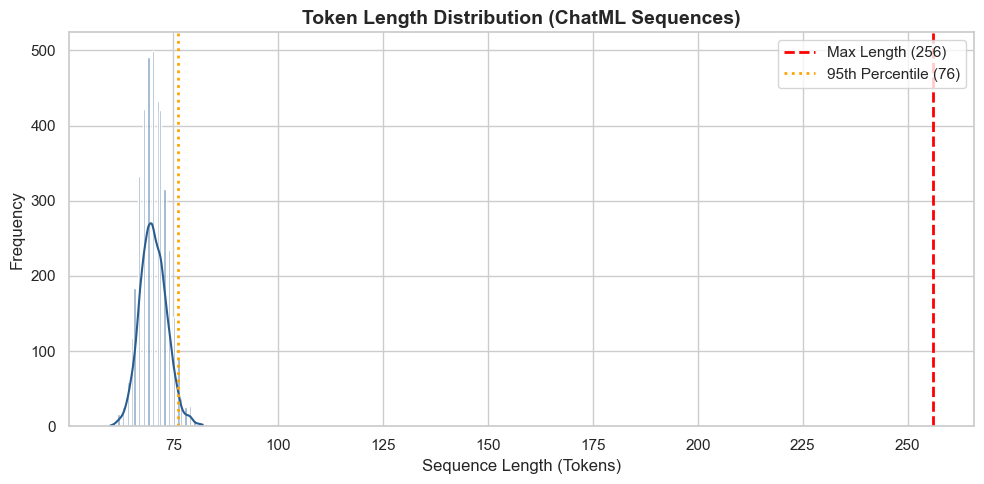


Inference: Truncation rate is 0.00% (< 5% threshold). Sequence length 256 safely accommodates the full instruction prompt and target JSON without truncating essential response tokens.


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

# Calculate non-padded token lengths for each sequence
sequence_lengths = np.sum(attention_mask, axis=1)

min_len = int(np.min(sequence_lengths))
max_len = int(np.max(sequence_lengths))
mean_len = float(np.mean(sequence_lengths))
p95_len = float(np.percentile(sequence_lengths, 95))
p99_len = float(np.percentile(sequence_lengths, 99))
num_truncated = int(np.sum(sequence_lengths == MAX_LENGTH))
truncation_pct = (num_truncated / len(sequence_lengths)) * 100

print("--- Token Distribution Statistics ---")
print(f"Min length:   {min_len} tokens")
print(f"Mean length:  {mean_len:.1f} tokens")
print(f"95th %-tile:  {p95_len:.1f} tokens")
print(f"99th %-tile:  {p99_len:.1f} tokens")
print(f"Max length:   {max_len} tokens (ceiling: {MAX_LENGTH})")
print(f"Truncated:    {num_truncated} sequences ({truncation_pct:.2f}%)")

# Plot token distribution
plt.figure(figsize=(10, 5))
sns.histplot(sequence_lengths, bins=40, kde=True, color="#2b5c8f")
plt.axvline(MAX_LENGTH, color="red", linestyle="--", linewidth=2, label=f"Max Length ({MAX_LENGTH})")
plt.axvline(p95_len, color="orange", linestyle=":", linewidth=2, label=f"95th Percentile ({p95_len:.0f})")
plt.title("Token Length Distribution (ChatML Sequences)", fontsize=14, fontweight="bold")
plt.xlabel("Sequence Length (Tokens)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

# Truncation assessment
if truncation_pct < 5.0:
    print(f"\nInference: Truncation rate is {truncation_pct:.2f}% (< 5% threshold). Sequence length {MAX_LENGTH} safely accommodates the full instruction prompt and target JSON without truncating essential response tokens.")
else:
    print(f"\nWarning: Truncation rate is {truncation_pct:.2f}% (>= 5%). Consider increasing MAX_LENGTH.")


#### **2.3.3 Prepare Retrieval Corpus [3 marks]**
**The Task:** Ingest the Markdown SOPs into LangChain Document objects ready to be embedded.

**Hints & Tips:**
* Use `TextLoader` from LangChain.
* Each `.md` file becomes one `Document` with `.page_content` and `.metadata`.
* These documents are embedded into ChromaDB in Notebook 4.

**Learner Inference:** These document objects form the knowledge base your bot retrieves from in Stages 3 and 4.

In [7]:
import glob
from langchain_community.document_loaders import TextLoader

# Locate corporate policies directory
candidates = [
    "corporate_policies",
    "../corporate_policies",
    "Files/Notebook/corporate_policies",
    "Files/Dataset/Dataset/sop_documents",
    "../Dataset/Dataset/sop_documents"
]
sop_dir = None
for cand in candidates:
    if os.path.exists(cand) and len(glob.glob(os.path.join(cand, "*.md"))) > 0:
        sop_dir = cand
        break

if not sop_dir:
    raise FileNotFoundError("Could not find corporate policies directory with .md files.")

sop_files = sorted(glob.glob(os.path.join(sop_dir, "*.md")))
print(f"Loading SOP documents from '{sop_dir}' ({len(sop_files)} files found)...")

documents = []
for fpath in sop_files:
    loader = TextLoader(fpath, encoding="utf-8")
    loaded_docs = loader.load()
    for doc in loaded_docs:
        doc.metadata["filename"] = os.path.basename(fpath)
        doc.metadata["title"] = os.path.splitext(os.path.basename(fpath))[0].replace("_", " ").title()
        documents.append(doc)

print(f"\nSuccessfully loaded {len(documents)} LangChain Document objects:")
for doc in documents:
    char_len = len(doc.page_content)
    word_len = len(doc.page_content.split())
    print(f"  - [{doc.metadata['filename']:28s}] {doc.metadata['title']:28s} : {char_len:5d} chars, {word_len:4d} words")

print("\nSample Document Metadata & Content Preview:")
print("Metadata:", documents[0].metadata)
print("Content Preview:\n", documents[0].page_content[:200], "...")


C:\Users\hp\AppData\Local\Temp\ipykernel_27500\2697819993.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import TextLoader


Loading SOP documents from 'corporate_policies' (13 files found)...



Successfully loaded 13 LangChain Document objects:
  - [account_recovery.md         ] Account Recovery             :  1553 chars,  240 words
  - [billing_disputes.md         ] Billing Disputes             :  1661 chars,  250 words
  - [data_privacy.md             ] Data Privacy                 :  1721 chars,  254 words
  - [escalation_matrix.md        ] Escalation Matrix            :  1550 chars,  234 words
  - [order_tracking.md           ] Order Tracking               :  1534 chars,  245 words
  - [password_reset.md           ] Password Reset               :  1604 chars,  258 words
  - [payment_methods.md          ] Payment Methods              :  1629 chars,  255 words
  - [product_return.md           ] Product Return               :  1570 chars,  243 words
  - [refund_policy.md            ] Refund Policy                :  1742 chars,  280 words
  - [shipping_delays.md          ] Shipping Delays              :  1542 chars,  247 words
  - [subscription_cancellation.md] Subscription 

### **Task 2.4: Create Dataset Partitions**

#### **2.4.1 Create Train, Validation, and Test Splits [5 marks]**
**The Task:** Split the tokenized dataset into Train (80%), Validation (10%), and Test (10%) partitions using stratified sampling. Demonstrate zero data leakage across all three.

**Hints & Tips:**
* Use `train_test_split` from sklearn with `stratify=df['intent']` so every intent appears in all splits.
* Split twice: first 80/20, then split the 20% into 50/50 (giving 10%/10%).
* The validation set is not optional — it is actively used during fine-tuning (Stage 4 / Notebook 6) for loss monitoring and early stopping.
* The test set must stay completely independent — used only for final evaluation.
* Verify zero overlap with set-intersection checks: `assert len(train_set & test_set) == 0`.
* Build a `df_test` DataFrame preserving readable `text`/`intent`/`category` columns for later scoring.

**Parameter Tuning:**
* Split ratio: `80/10/10` (recommended) or `70/15/15`. Any alternative must be justified.

**Why we are doing it:** To guarantee isolated, unseen data for unbiased evaluation, and a validation set for overfitting detection.
**How we are doing it:** Stratified sklearn splits with explicit programmatic leakage verification.

**Learner Inference:** Testing on data the model trained on gives false confidence (leakage). The held-out test split proves your model handles completely new phrasing; the validation split tells you when to stop training.

In [8]:
from sklearn.model_selection import train_test_split
from datasets import Dataset

# 1. Stratified 80/10/10 splitting using df['intent']
indices = np.arange(len(df))

# First split: 80% train, 20% temp (val + test)
train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.20,
    random_state=42,
    stratify=df['intent']
)

# Second split: split 20% temp equally into 10% validation and 10% test
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    random_state=42,
    stratify=df.iloc[temp_idx]['intent']
)

print("--- Partition Sizes ---")
print(f"Train set:      {len(train_idx):,} records ({len(train_idx)/len(df)*100:.1f}%)")
print(f"Validation set: {len(val_idx):,} records ({len(val_idx)/len(df)*100:.1f}%)")
print(f"Test set:       {len(test_idx):,} records ({len(test_idx)/len(df)*100:.1f}%)")

# 2. Verify all intents exist across all 3 partitions
train_intents = set(df.iloc[train_idx]['intent'])
val_intents = set(df.iloc[val_idx]['intent'])
test_intents = set(df.iloc[test_idx]['intent'])

print(f"\nUnique intents - Train: {len(train_intents)}, Val: {len(val_intents)}, Test: {len(test_intents)}")
assert len(train_intents) == df['intent'].nunique(), "Missing intents in Train split!"
assert len(val_intents) == df['intent'].nunique(), "Missing intents in Validation split!"
assert len(test_intents) == df['intent'].nunique(), "Missing intents in Test split!"
print("Intent stratification verified: all 27 intents present across Train, Val, and Test.")

# 3. Programmatic Zero Data Leakage Verification
train_texts = set(df.iloc[train_idx]['instruction'].str.lower().str.strip())
val_texts = set(df.iloc[val_idx]['instruction'].str.lower().str.strip())
test_texts = set(df.iloc[test_idx]['instruction'].str.lower().str.strip())

leak_train_val = train_texts.intersection(val_texts)
leak_train_test = train_texts.intersection(test_texts)
leak_val_test = val_texts.intersection(test_texts)

print("\n--- Zero Leakage Verification ---")
print(f"Leakage (Train & Val):  {len(leak_train_val)}")
print(f"Leakage (Train & Test): {len(leak_train_test)}")
print(f"Leakage (Val & Test):   {len(leak_val_test)}")

assert len(leak_train_val) == 0, f"Data leakage detected between Train and Val: {len(leak_train_val)} overlapping instructions"
assert len(leak_train_test) == 0, f"Data leakage detected between Train and Test: {len(leak_train_test)} overlapping instructions"
assert len(leak_val_test) == 0, f"Data leakage detected between Val and Test: {len(leak_val_test)} overlapping instructions"
print("ASSERTION PASSED: Strictly ZERO data leakage across all three partitions!")

# 4. Build df_test preserving human-readable text and evaluation columns
df_test = df.iloc[test_idx].copy().reset_index(drop=True)
print(f"\nBuilt df_test with shape: {df_test.shape}")


--- Partition Sizes ---
Train set:      3,121 records (80.0%)
Validation set: 390 records (10.0%)
Test set:       391 records (10.0%)

Unique intents - Train: 27, Val: 27, Test: 27
Intent stratification verified: all 27 intents present across Train, Val, and Test.

--- Zero Leakage Verification ---
Leakage (Train & Val):  0
Leakage (Train & Test): 0
Leakage (Val & Test):   0
ASSERTION PASSED: Strictly ZERO data leakage across all three partitions!

Built df_test with shape: (391, 6)


---
## Save Artifacts for Downstream Notebooks

**IMPORTANT:** These cells save all datasets. Notebooks 5, 6, and 7 depend on them.

In [9]:
# 1. Package tokenized splits into Hugging Face Datasets
train_ds = Dataset.from_dict({
    "input_ids": input_ids[train_idx].tolist(),
    "attention_mask": attention_mask[train_idx].tolist(),
    "labels": labels[train_idx].tolist()
})

val_ds = Dataset.from_dict({
    "input_ids": input_ids[val_idx].tolist(),
    "attention_mask": attention_mask[val_idx].tolist(),
    "labels": labels[val_idx].tolist()
})

test_ds = Dataset.from_dict({
    "input_ids": input_ids[test_idx].tolist(),
    "attention_mask": attention_mask[test_idx].tolist(),
    "labels": labels[test_idx].tolist()
})

# 2. Save tokenized datasets to disk
train_ds.save_to_disk("tokenized_train")
val_ds.save_to_disk("tokenized_valid")
test_ds.save_to_disk("tokenized_test")
print("Saved Hugging Face tokenized datasets to './tokenized_train', './tokenized_valid', './tokenized_test'")

# Also save copies to root if current dir is Notebook
for name, ds in [("tokenized_train", train_ds), ("tokenized_valid", val_ds), ("tokenized_test", test_ds)]:
    root_path = os.path.join("..", "..", name)
    if os.path.exists(os.path.join("..", "..", "Files")):
        ds.save_to_disk(root_path)

# 3. Save df_test.csv
test_csv_path = "df_test.csv"
df_test.to_csv(test_csv_path, index=False)
print(f"Saved test set to '{test_csv_path}' ({len(df_test)} rows)")

# Save extra copies for easy resolution in downstream notebooks
extra_test_paths = [
    os.path.join("..", "..", test_csv_path),
    os.path.join("..", "Dataset", test_csv_path),
    os.path.join("Files", "Notebook", test_csv_path),
    os.path.join("Files", "Dataset", test_csv_path)
]
for p in extra_test_paths:
    parent = os.path.dirname(p)
    if parent and os.path.exists(parent):
        df_test.to_csv(p, index=False)
        print(f"Saved copy to: {p}")

# 4. Verify saved artifacts
from datasets import load_from_disk
reloaded_train = load_from_disk("tokenized_train")
reloaded_val = load_from_disk("tokenized_valid")
reloaded_test = load_from_disk("tokenized_test")
reloaded_df_test = pd.read_csv(test_csv_path)

print("\n--- Artifacts Verification ---")
print(f"tokenized_train: {reloaded_train}")
print(f"tokenized_valid: {reloaded_val}")
print(f"tokenized_test:  {reloaded_test}")
print(f"df_test.csv:     {reloaded_df_test.shape} with columns {list(reloaded_df_test.columns)}")


Saving the dataset (0/1 shards):   0%|          | 0/3121 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/390 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/391 [00:00<?, ? examples/s]

Saved Hugging Face tokenized datasets to './tokenized_train', './tokenized_valid', './tokenized_test'


Saving the dataset (0/1 shards):   0%|          | 0/3121 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/390 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/391 [00:00<?, ? examples/s]

Saved test set to 'df_test.csv' (391 rows)
Saved copy to: ..\..\df_test.csv
Saved copy to: ..\Dataset\df_test.csv



--- Artifacts Verification ---
tokenized_train: Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 3121
})
tokenized_valid: Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 390
})
tokenized_test:  Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 391
})
df_test.csv:     (391, 6) with columns ['flags', 'instruction', 'category', 'intent', 'response', 'text']


---
## END-OF-NOTEBOOK CHECKLIST

> **IMPORTANT: Verify all items before proceeding to Notebook 3.**

- [ ] `sampled_data.csv` loaded
- [ ] **Duplicates + invalid records removed (normalised dedup)** ← _Task 2.1.1_
- [ ] Data standardised (intent=lower, category=UPPER)
- [ ] ChatML formatting applied and validated (valid JSON)
- [ ] Tokenization completed with `-100` label masking
- [ ] Token distribution analysed — truncation risk assessed
- [ ] Retrieval corpus loaded from `.md` files
- [ ] **Stratified Train/Valid/Test split** with all intents in every partition
- [ ] **Zero leakage verified** via set-intersection checks
- [ ] **`./tokenized_train/` + `./tokenized_valid/` saved** ← _CRITICAL for NB6_
- [ ] **`df_test.csv` saved** ← _CRITICAL for NB5 and NB7_

**If any item is unchecked, fix it before moving on.**